# 🟡 Lesson 15 — SciPy

**Level: Intermediate** · Statistics, interpolation, optimisation and signal tools — the scientific toolbox on top of NumPy.

*Part of the companion package for [python_for_geologists](https://github.com/kevinalexandr19/python_for_geologists) by Kevin Alexander Gomez.*

In [1]:
import numpy as np
import pandas as pd
from scipy import stats, interpolate
from pathlib import Path
import scipy
print("scipy", scipy.__version__)

DATA = Path("..") / "data"
assay = pd.read_csv(DATA / "assay.csv")
cu = assay["CU_pct"].dropna().values

scipy 1.16.3


## 1. Descriptive statistics on real grades

In [2]:
d = stats.describe(cu)
print(f"n={d.nobs}  mean={d.mean:.3f}  var={d.variance:.3f}  skew={d.skewness:.2f}")
print("Grades are right-skewed (skewness >> 0) - typical for ore deposits.")

n=7951  mean=0.952  var=0.840  skew=2.37
Grades are right-skewed (skewness >> 0) - typical for ore deposits.


## 2. Fit a lognormal distribution — the classic grade model

In [3]:
cu_pos = cu[cu > 0]                    # lognormal is defined only for x > 0
print(f"dropped {len(cu) - len(cu_pos)} zero-grade intervals")

shape, loc, scale = stats.lognorm.fit(cu_pos, floc=0)
p90 = stats.lognorm.ppf(0.90, shape, loc, scale)
print(f"lognormal fit: sigma={shape:.2f}, median={scale:.3f}%")
print(f"P90 grade    : {p90:.2f}% Cu (10% of intervals exceed this)")

# goodness of fit
ks = stats.kstest(cu_pos, "lognorm", args=(shape, loc, scale))
print(f"KS test p-value: {ks.pvalue:.3f}")

dropped 7 zero-grade intervals
lognormal fit: sigma=0.96, median=0.629%
P90 grade    : 2.15% Cu (10% of intervals exceed this)
KS test p-value: 0.000


## 3. Hypothesis test — do two drillholes have different grades?

In [4]:
ids = assay["ID"].unique()
a = assay.loc[assay["ID"] == ids[0], "CU_pct"].dropna()
b = assay.loc[assay["ID"] == ids[1], "CU_pct"].dropna()

t = stats.mannwhitneyu(a, b)          # non-parametric: safe for skewed grades
print(f"{ids[0]} median={a.median():.2f} vs {ids[1]} median={b.median():.2f}")
print(f"Mann-Whitney p = {t.pvalue:.4f} ->", "different" if t.pvalue < 0.05 else "no significant difference")

DH001 median=0.57 vs DH002 median=0.46
Mann-Whitney p = 0.0327 -> different


## 4. 1-D interpolation — resample a downhole log

In [5]:
dh = assay[assay["ID"] == ids[0]]
mid = ((dh["FROM"] + dh["TO"]) / 2).values
g = dh["CU_pct"].values

f = interpolate.interp1d(mid, g, kind="linear")
new_depths = np.arange(mid.min(), mid.max(), 0.5)      # every 0.5 m
print("resampled", len(mid), "->", len(new_depths), "points")
print("grade at 25.0 m: %.3f %% Cu" % float(f(25.0)))

resampled 99 -> 393 points
grade at 25.0 m: 1.070 % Cu


## 5. 2-D interpolation — grid scattered geochem samples

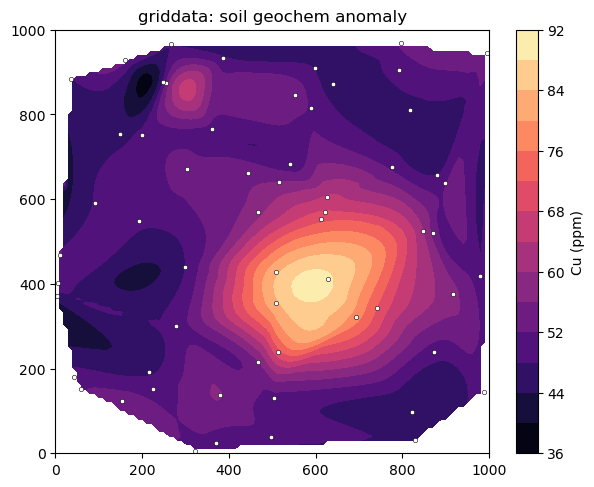

In [6]:
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
xs, ys = rng.uniform(0, 1000, 60), rng.uniform(0, 1000, 60)
zs = 50 + 40*np.exp(-((xs-600)**2 + (ys-400)**2)/200**2) + rng.normal(0, 3, 60)

gx, gy = np.mgrid[0:1000:100j, 0:1000:100j]
gz = griddata((xs, ys), zs, (gx, gy), method="cubic")

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.contourf(gx, gy, gz, levels=15, cmap="magma")
ax.scatter(xs, ys, c="white", s=10, edgecolor="k", lw=0.4)
fig.colorbar(im, label="Cu (ppm)"); ax.set_title("griddata: soil geochem anomaly")
plt.show()

### ✏️ Try it
1. Fit a normal distribution to `log(cu)` and confirm it matches the lognormal fit.
2. Try `method='nearest'` vs `'cubic'` in `griddata` — which suits sparse drilling better?

📚 Docs: https://docs.scipy.org/doc/scipy/